In [ ]:
import zipfile
zip = zipfile.ZipFile('/content/archive (3).zip')
zip.extractall('/content/')
zip.close()

In [ ]:
from tensorflow.keras.utils import image_dataset_from_directory

In [ ]:
train_dataset = image_dataset_from_directory(
    "/content/Training",
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

valid_dataset = image_dataset_from_directory(
    "/content/Testing",
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.


In [ ]:
train_dataset.class_names

['glioma', 'meningioma', 'notumor', 'pituitary']

In [ ]:
import tensorflow as tf

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
valid_dataset = valid_dataset.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import GlobalAveragePooling2D

In [ ]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers[-30:]:
    layer.trainable = True

model = Sequential()
model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(4, activation='softmax'))

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 23,797,380 (90.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
earlystopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

In [ ]:
history = model.fit(train_dataset, validation_data=valid_dataset, epochs=50, callbacks=[earlystopping, reduce_lr])

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 128s 365ms/step - accuracy: 0.7764 - loss: 0.6180 - val_accuracy: 0.2494 - val_loss: 1.9378 - learning_rate: 1.0000e-05
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 59s 337ms/step - accuracy: 0.9305 - loss: 0.2096 - val_accuracy: 0.2544 - val_loss: 2.0526 - learning_rate: 1.0000e-05
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 59s 340ms/step - accuracy: 0.9684 - loss: 0.1078 - val_accuracy: 0.2650 - val_loss: 1.6810 - learning_rate: 1.0000e-05
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 59s 338ms/step - accuracy: 0.9830 - loss: 0.0663 - val_accuracy: 0.3931 - val_loss: 1.3360 - learning_rate: 1.0000e-05
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 60s 343ms/step - accuracy: 0.9936 - loss: 0.0335 - val_accuracy: 0.5938 - val_loss: 0.9787 - learning_rate: 1.0000e-05
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 59s 338ms/step - accuracy: 0.9954 - loss: 0.0228 - val_accuracy: 0.7725 - val_loss: 0.6887 - learning_rate: 1.0000e-05
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 83s 3

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0, 0.5, 'LOSS')

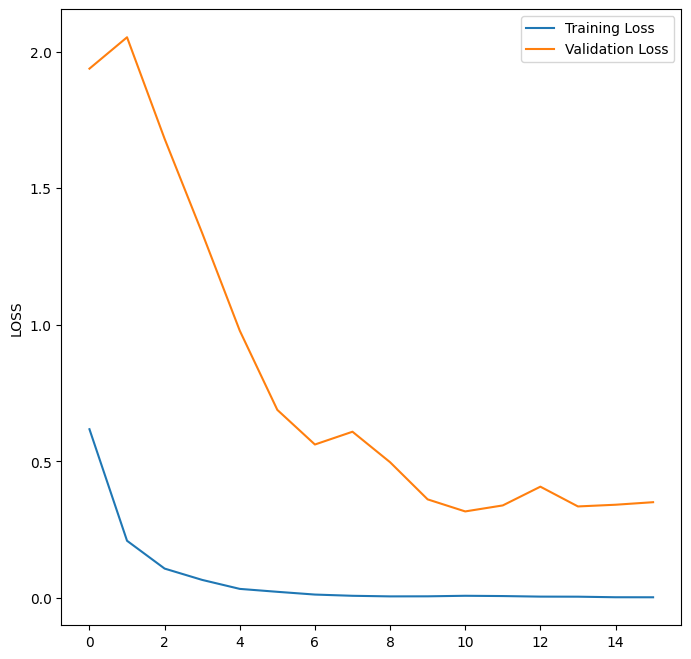

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
figure = plt.figure(figsize=(8, 8))
plt.plot(history.epoch, loss, label='Training Loss')
plt.plot(history.epoch, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('LOSS')

Text(0, 0.5, 'Accuracy')

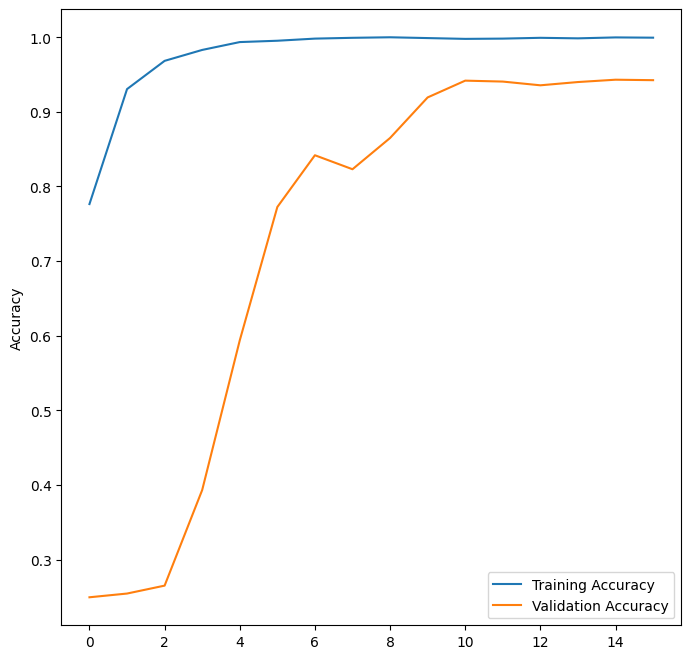

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
figure = plt.figure(figsize=(8, 8))
plt.plot(history.epoch, acc, label='Training Accuracy')
plt.plot(history.epoch, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')

In [ ]:
model.save("cnn_model.h5")